#### Imports

In [23]:
# work with files 
import yaml
import copy

# do Math stuff
from itertools import permutations
import numpy as np
import sys
import os

from IPython.core.display import display, HTML


# Suite2p for TIFF file analysis
import suite2p
from suite2p.run_s2p import run_s2p, default_ops
from suite2p.registration import register

module_path = os.path.abspath(os.path.join('../'))
sys.path.append(module_path)
from temp import *
from manifolds.donlabtools.utils.calcium import calcium
from manifolds.donlabtools.utils.calcium.calcium import *

# usefull jupyter settings
%matplotlib inline
#%matplotlib tk
%autosave 180
%load_ext autoreload
%autoreload 2
%config Completer.use_jedi = False

Autosaving every 180 seconds
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## HowTo

In [6]:
### Define yx-shift for every session

In [2]:
# Load wanted animal data from root directory
root_dir = "D:\\Animals" 
Animal.root_dir = "D:\\Animals" 
#day1_20230303
#lastday_20230309
wanted_animal_ids = ["DON-011733"] #["all"]
wanted_session_ids = ["all"] #["day0", "20230303", "20230309"] #["all"]
animals = load_all(root_dir, wanted_animal_ids=wanted_animal_ids, wanted_session_ids=wanted_session_ids, print_loading=True)


Added animal: DON-011733
Loading session: DON-011733 20230303
Loading cabincorr data from D:\Animals\DON-011733\20230303\plane0
Loading session: DON-011733 20230304
Loading cabincorr data from D:\Animals\DON-011733\20230304\plane0
Loading session: DON-011733 20230305
Loading cabincorr data from D:\Animals\DON-011733\20230305\plane0
Loading session: DON-011733 20230306
Loading cabincorr data from D:\Animals\DON-011733\20230306\plane0
Loading session: DON-011733 20230307
Loading cabincorr data from D:\Animals\DON-011733\20230307\plane0
Loading session: DON-011733 20230308
Loading cabincorr data from D:\Animals\DON-011733\20230308\plane0
Loading session: DON-011733 20230309
Loading cabincorr data from D:\Animals\DON-011733\20230309\plane0
Loading session: DON-011733 day0
Loading cabincorr data from D:\Animals\DON-011733\day0\plane0


In [3]:
#set reference session
animal_id = "DON-011733"
session_id = "day0"#"20230303"
animal = animals[animal_id].sessions[session_id]
sessions = animal.sessions 
reference_session = sessions[session_id]

In [4]:
# Define xy shift
merger = Merger()
merger.set_yx_shifts(reference_session, sessions, n_frames_to_be_acquired=1000, num_align_frames=1000)
for session_id, session in sessions.items():  
    print(f"{session_id} shift: {session.yx_shift}")

20230303 shift: [-13, 3]
20230304 shift: [3, 0]
20230305 shift: [-7, -1]
20230306 shift: [-6, 4]
20230307 shift: [-12, 9]
20230308 shift: [-5, 5]
20230309 shift: [-4, 6]
day0 shift: [0, 0]


## Explanation

### Define yx-shift for every session + Visualization

In [ ]:
"""Only for understanding purposes. The correct procedure is using shown in section HowTo"""
#define reference image
animal_id = "DON-011733"
session_id = "day0"#"20230303"
animal = animals[animal_id]
sessions = animal.sessions 
reference_session = sessions[session_id]

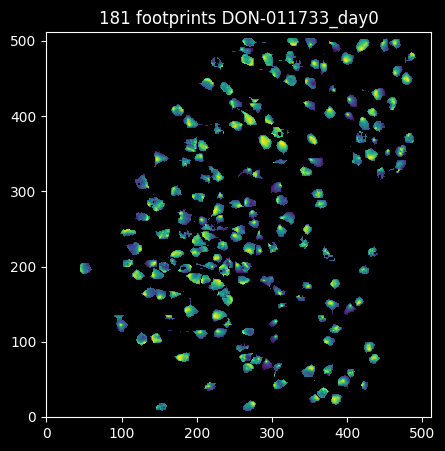

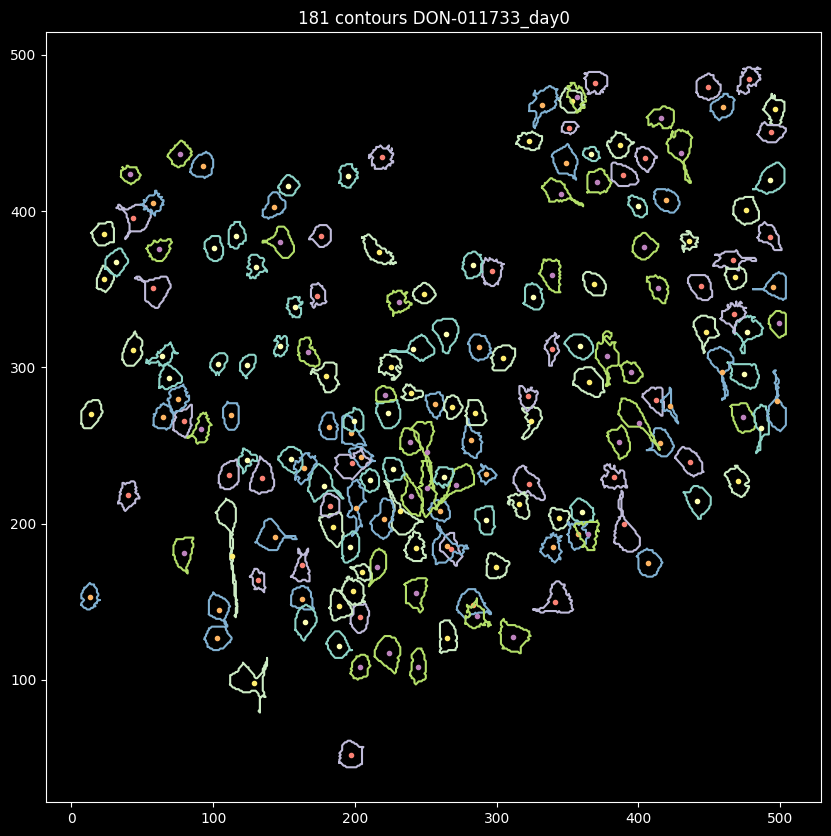

In [16]:
"""Only for understanding purposes. The correct procedure is using shown in section HowTo"""
viz = Vizualizer()
viz.session_footprints(reference_session, figsize=(5,5))
viz.session_contours(reference_session, figsize=(10,10), plot_center=True)

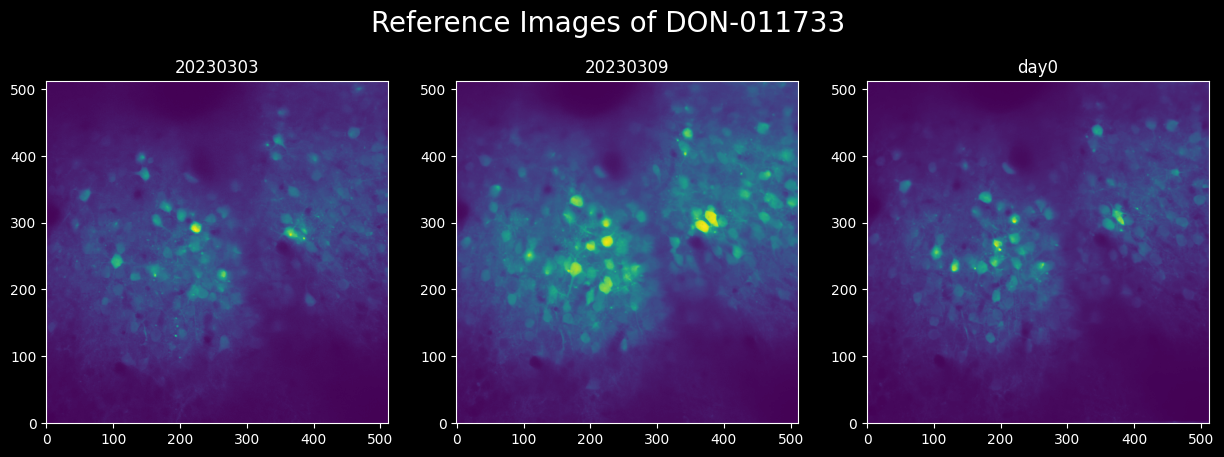

In [6]:
"""Only for understanding purposes. The correct procedure is using shown in section HowTo"""
# Calculating yx_shifts for all sessions
for i, s in sessions.items():
    s.refImg = None
refImg = reference_session.get_reference_image(n_frames_to_be_acquired=1000)
refAndMasks = register.compute_reference_masks(refImg, reference_session.ops)

# Plot reference Images
# TODO: Plot reference images for all sessions
for session_id, sess in sessions.items():
    if session_id == reference_session.session_id:
        continue   
    sess.get_reference_image()
    
viz.multi_session_refImg(sessions, num_images_x=3)


[0, 0]

In [44]:
"""Only for understanding purposes. The correct procedure is using shown in section HowTo"""
# create yx_shifts for all sessions
refImg = reference_session.get_reference_image()
refAndMasks = register.compute_reference_masks(refImg, reference_session.ops)
for session_id, session in sessions.items():
    if session_id == reference_session.session_id:
        continue   
    session.set_yx_shift(refAndMasks, num_align_frames=1000)
    print(f"{session_id} shift: {session.yx_shift}")

#Plot session contour shift combinations for own Algorithm and for human evaluated values
viz = Vizualizer()
session_ids = list(sessions.keys())
combinations = list(permutations(session_ids, 2))
session_id_numbering = range(len(session_ids))
numbering_combinations = list(permutations(session_id_numbering, 2))
for num_combination, combination in zip(numbering_combinations, combinations):
    if num_combination[0] < num_combination[1]:
        viz.multi_session_contours(sessions, combination=combination, plot_center=True, shift=False, figsize=(20, 20))
        viz.multi_session_contours(sessions, combination=combination, plot_center=True, shift="algo", figsize=(20, 20), comment=f"_algo")
        viz.multi_session_contours(sessions, combination=combination, plot_center=True, shift="human", figsize=(20, 20), comment=f"_human")

# for every session: take the first 100 frames create a .gif and afterwards a .mp4 video
for session_id, session in sessions.items():
    l = Binary_loader()
    num_frames = 100
    binary_frames = l.load_binary(session.session_dir, num_frames)
    save_dir = os.path.join(root_dir, "figures")
    gif_name = f"{session.animal_id}_{session.session_id}_0-{num_frames}.gif"
    ani = l.binary_frames_to_animation(binary_frames, frame_range=[0, num_frames], save_dir=save_dir, comment=f"{session.animal_id}_{session.session_id}")
    gif_to_mp4(os.path.join(save_dir, gif_name))

20230303 shift: [-13, 3]
20230309 shift: [-4, 6]


### Merge all Subsessions to create full animal fluorescence data

In [27]:
#Plot session contour shift combinations for own Algorithm and for human evaluated values
viz = Vizualizer()
del viz
viz = Vizualizer()
session_ids = list(sessions.keys())
combinations = list(permutations(session_ids, 2))
session_id_numbering = range(len(session_ids))
numbering_combinations = list(permutations(session_id_numbering, 2))
for num_combination, combination in zip(numbering_combinations, combinations):
    if num_combination[0] < num_combination[1]:
        viz.multi_session_contours(sessions, combination=combination, plot_center=True, shift=False, figsize=(20, 20))
        viz.multi_session_contours(sessions, combination=combination, plot_center=True, shift="algo", figsize=(20, 20), comment=f"_algo")
        viz.multi_session_contours(sessions, combination=combination, plot_center=True, shift="human", figsize=(20, 20), comment=f"_human")

In [ ]:
class Merger:
    """
    Merges indiviual MUnits/Subsession of a Session
    """
    def shift_stat_cells(self, stat, yx_shift, image_x_size=512, image_y_size=512):
        # stat files first value ist y-value second is x-value
        new_stat = copy.deepcopy(stat)

        for num, cell_stat in enumerate(new_stat):
            y_shifted = []
            for y in cell_stat["ypix"]:
                y_shifted.append(y-yx_shift[0])
            cell_stat["ypix"] = np.array(y_shifted)
            
            x_shifted = []
            for x in cell_stat["xpix"]:
                x_shifted.append(x-yx_shift[1])
            cell_stat["xpix"] = np.array(x_shifted)

            #center of cell_stat
            med = cell_stat["med"]
            med_shifted = [med[0]-yx_shift[0], med[1]-yx_shift[1]]
            cell_stat["med"] = med_shifted
        return new_stat
    
    def merge_stat(self, units, best_unit, parallel=True, image_x_size=512, image_y_size=512):
        """
        shift and merge, deduplicate, stat files with best_unit as reference position
        """
        num_batches = get_num_batches_based_on_available_ram()
        
        shifted_unit_stat_no_abroad = self.remove_abroad_cells(best_unit.c.stat, units, image_x_size=image_x_size, image_y_size=image_y_size)
        merged_footprints = self.stat_to_footprints(shifted_unit_stat_no_abroad)
        merged_stat = shifted_unit_stat_no_abroad
        for unit_id, unit in units.items():
            if unit_id == best_unit.unit_id:
                continue    
            shifted_unit_stat = self.shift_stat_cells(unit.c.stat, yx_shift=unit.yx_shift, image_x_size=image_x_size, image_y_size=image_y_size)
            shifted_unit_stat_no_abroad = self.remove_abroad_cells(shifted_unit_stat, units, image_x_size=image_x_size, image_y_size=image_y_size)
            shifted_footprints = self.stat_to_footprints(shifted_unit_stat_no_abroad)
            clean_cell_ids, merged_footprints = self.merge_deduplicate_footprints(merged_footprints, shifted_footprints, parallel=parallel, num_batches=num_batches)
            merged_stat = np.concatenate([merged_stat, shifted_unit_stat_no_abroad])[clean_cell_ids]
        return merged_stat
    
    def remove_abroad_cells(self, stat, units, image_x_size=512, image_y_size=512):
        # removing out of bound cells 
        remove_cells = []
        for cell_num, cell in enumerate(stat):
            abroad = False
            #check for every shift 
            for unit_id, unit in units.items():
                if abroad:
                    break
                yx_shift = unit.yx_shift
                for axis in ["ypix", "xpix"]:
                    shift = yx_shift[0] if axis=="ypix" else yx_shift[1]
                    shifted = cell[axis]+shift

                    # check if cell is out of bound
                    max_location = image_y_size if axis=="ypix" else image_x_size
                    if sum(shifted>=max_location)>0 or sum(shifted<0)>0:
                        abroad = True
                        break    
            if abroad:
                remove_cells.append(cell_num)
                
        for abroad_cell in remove_cells[::-1]:
            stat = np.delete(stat, abroad_cell)
            print(f"removed cell {abroad_cell}")
        return stat

    def merge_s2p_files(self, units, stat, ops):
        """
        Merges F, Fneu, spks, iscell from individual Units
        Does not merge the individual corrected stat files
        Does not merge ops
        """
        path = units[list(units.keys())[0]].suite2p_path
        path = os.path.join(path, "plane0")
        merged_F = np.load(os.path.join(path, "F.npy"))
        merged_Fneu = np.load(os.path.join(path,   "Fneu.npy"))
        merged_spks = np.load(os.path.join(path,   "spks.npy"))
        merged_iscell = np.load(os.path.join(path, "iscell.npy"))
        for unit_id, unit in units.items():
            if unit_id == list(units.keys())[0]:
                continue
            path = unit.suite2p_path
            path = os.path.join(path, "plane0")
            F =  np.load(os.path.join(path, "F.npy"))
            merged_F = np.concatenate([merged_F, F], axis=1)
            Fneu =  np.load(os.path.join(path, "Fneu.npy"))
            merged_Fneu = np.concatenate([merged_Fneu, Fneu], axis=1)
            spks =  np.load(os.path.join(path, "spks.npy"))
            merged_spks = np.concatenate([merged_spks, spks], axis=1)
            is_cell = np.load(os.path.join(path, "iscell.npy"))
            merged_iscell *= is_cell
        
        root = path.split("suite2p")[0]
        merged_s2p_path = os.path.join(root, "suite2p_merged")
        dir_exist_create(merged_s2p_path)
        merged_s2p_path = os.path.join(root, "suite2p_merged", "plane0")
        dir_exist_create(merged_s2p_path)

        np.save(os.path.join(merged_s2p_path, "F.npy"), merged_F)
        np.save(os.path.join(merged_s2p_path, "Fneu.npy"), merged_Fneu)
        np.save(os.path.join(merged_s2p_path, "spks.npy"), merged_spks)
        np.save(os.path.join(merged_s2p_path, "iscell.npy"), merged_iscell)

        np.save(os.path.join(merged_s2p_path, "stat.npy"), stat)
        np.save(os.path.join(merged_s2p_path, "ops.npy"), ops)
        return merged_F, merged_Fneu, merged_spks, merged_iscell
    
    def stat_to_footprints(self, stat, dims=[512, 512]):
        imgs = []
        for k in range(len(stat)):
            x = stat[k]['xpix']
            y = stat[k]['ypix']

            # save footprint
            img_temp = np.zeros((dims[0], dims[1]))
            img_temp[x, y] = stat[k]['lam']

            img_temp_norm = (img_temp - np.min(img_temp)) / (np.max(img_temp) - np.min(img_temp))
            imgs.append(img_temp_norm)

        imgs = np.array(imgs)

        footprints = imgs
        return footprints

    def find_overlaps1(self, ids, footprints):
        #
        intersections = []
        for k in ids:
            temp1 = footprints[k]
            idx1 = np.vstack(np.where(temp1 > 0)).T

            #
            for p in range(k + 1, footprints.shape[0], 1):
                temp2 = footprints[p]
                idx2 = np.vstack(np.where(temp2 > 0)).T
                res = array_row_intersection(idx1, idx2)

                #
                if len(res) > 0:
                    percent1 = res.shape[0] / idx1.shape[0]
                    percent2 = res.shape[0] / idx2.shape[0]
                    intersections.append([k, p, res.shape[0], percent1, percent2])
        #
        return intersections

    def generate_batch_cell_overlaps(self, footprints, parallel=True, recompute_overlap=False, n_cores=16, num_batches=3):
        # this computes spatial overlaps between cells; doesn't take into account temporal correlations
            
        print ("... computing cell overlaps ...")
        
        num_footprints = footprints.shape[0]
        num_min_cells_per_process = 10
        num_parallel_processes = 30 if num_footprints/30>num_min_cells_per_process else int(num_footprints/num_min_cells_per_process)
        ids = np.array_split(np.arange(num_footprints, dtype="int64"), num_parallel_processes)

        if num_batches > num_parallel_processes:
            num_batches = num_parallel_processes

        #TODO: will results in an error, if np.array_split is used on inhomogeneouse data like ids on Scicore
        batches = np.array_split(ids, num_batches) if num_batches!=1 else [ids]
        results = np.array([])
        num_cells = 0
        for batch in batches:
            res = parmap.map(find_overlaps1,
                            batch,
                            footprints,
                            #c.footprints_bin,
                            pm_processes=16,
                            pm_pbar=True,
                            pm_parallel=parallel)
            for cell_batch in res:
                num_cells += len(cell_batch)
                for cell in cell_batch:
                    results = np.append(results, cell)
        results = results.reshape(num_cells, 5)
        res = [results]
        df = make_overlap_database(res)
        return df

    def find_candidate_neurons_overlaps(self, df_overlaps, corr_array=None, deduplication_use_correlations=False, corr_max_percent_overlap=0.25, corr_threshold=0.3):

        dist_corr_matrix = []
        for index, row in df_overlaps.iterrows():
            cell1 = int(row['cell1'])
            cell2 = int(row['cell2'])
            percent1 = row['percent_cell1']
            percent2 = row['percent_cell2']

            if deduplication_use_correlations:

                if cell1 < cell2:
                    corr = corr_array[cell1, cell2, 0]
                else:
                    corr = corr_array[cell2, cell1, 0]
            else:
                corr = 0
            dist_corr_matrix.append([cell1, cell2, corr, max(percent1, percent2)])
        dist_corr_matrix = np.vstack(dist_corr_matrix)
        #####################################################
        # check max overlap
        idx1 = np.where(dist_corr_matrix[:, 3] >= corr_max_percent_overlap)[0]
        
        # skipping correlations is not a good idea
        #   but is a requirement for computing deduplications when correlations data cannot be computed first
        if deduplication_use_correlations:
            idx2 = np.where(dist_corr_matrix[idx1, 2] >= corr_threshold)[0]   # note these are zscore thresholds for zscore method
            idx3 = idx1[idx2]
        else:
            idx3 = idx1
        #
        candidate_neurons = dist_corr_matrix[idx3][:, :2]
        return candidate_neurons

    def make_correlated_neuron_graph(self, num_cells, candidate_neurons):
        adjacency = np.zeros((num_cells, num_cells))
        for i in candidate_neurons:
            adjacency[int(i[0]), int(i[1])] = 1

        G = nx.Graph(adjacency)
        G.remove_nodes_from(list(nx.isolates(G)))
        return G

    def delete_duplicate_cells(self, num_cells, G, corr_delete_method='highest_connected_no_corr'):
        # delete multi node networks
        #
        if corr_delete_method=='highest_connected_no_corr':
            connected_cells, removed_cells = del_highest_connected_nodes_without_corr(G)
        # 
        print ("Removed cells: ", len(removed_cells))
        clean_cells = np.delete(np.arange(num_cells),
                                removed_cells)

        #
        clean_cell_ids = clean_cells
        removed_cell_ids = removed_cells
        connected_cell_ids = connected_cells
        return clean_cell_ids

    def merge_deduplicate_footprints(self, footprints1, footprints2, parallel=True, num_batches=4):
        merged_footprints = np.concatenate([footprints1, footprints2])
        num_cells = len(merged_footprints)

        df_overlaps = self.generate_batch_cell_overlaps(merged_footprints, recompute_overlap=True, parallel=parallel, num_batches=num_batches)
        candidate_neurons = self.find_candidate_neurons_overlaps(df_overlaps, corr_array=None, deduplication_use_correlations=False, corr_max_percent_overlap=0.25, corr_threshold=0.3)
        G = self.make_correlated_neuron_graph(num_cells, candidate_neurons)
        clean_cell_ids = self.delete_duplicate_cells(num_cells, G)
        cleaned_merged_footprints = merged_footprints[clean_cell_ids]
        return clean_cell_ids, cleaned_merged_footprints
    
    def shift_update_unit_s2p_files(self, unit, new_stat, image_x_size=512, image_y_size=512, deduplicate = False):
        data_path = os.path.join(unit.suite2p_path, "plane0")
        # shift merged mask
        shift_to_unit = np.array([-1]) * unit.yx_shift
        shifted_unit_stat = self.shift_stat_cells(new_stat, yx_shift=shift_to_unit, image_x_size=image_x_size, image_y_size=image_y_size)

        backup_s2p_files(data_path, note="backup")
        update_s2p_files(data_path, shifted_unit_stat)